This example showcases that number of segments the piping section is split into does not influence the final temperature.

Here, we import 3 examples prepared by me beforehand of the same pipe. The difference is in the number of sections the pipe is split into.

First dataframe is split to 4 segments, second to 200 segments and third is just 1 segment. If integration solution is correct there should be no difference in how small steps we will take, because integral soultion should be exact.

You can see that each A* dataframe shows the same final fluid and surface temperatures. It can also be seen on the plotted graph.

NOTE: I have changed k_insulation to 1, so the change can be clearly seen on the graph.

In [1]:
from py_files.data_prep import *
from py_files.data_utils import *
from py_files.mainframe import *
from py_files.data_example import *
import matplotlib.pyplot as plt

In [2]:
user_array = user_table_example()[:3]
properties_table = properties_table_example()[0]
properties_table['k_insulation'] = 1
properties_table['solar_flux'] = 0

In [3]:
user_table = []
for i in range(len(user_array)):
    user_table.append(
        user_table_prepare(
            pd.DataFrame(user_array[i]),
            'imperial'
        )
    )
    print('User Table', i)
    display(user_table[i].tail())
    print('-'*80, '\n'*2)

User Table 0


,pipe_outer_diameter,pipe_inner_diameter,insulation_thickness,segment_length
0,4.0,3.8,0.1,500.0
1,4.0,3.8,0.1,500.0
2,4.0,3.8,0.1,500.0
3,4.0,3.8,0.1,500.0


-------------------------------------------------------------------------------- 


User Table 1


,pipe_outer_diameter,pipe_inner_diameter,insulation_thickness,segment_length
195,4.0,3.8,0.1,10.0
196,4.0,3.8,0.1,10.0
197,4.0,3.8,0.1,10.0
198,4.0,3.8,0.1,10.0
199,4.0,3.8,0.1,10.0


-------------------------------------------------------------------------------- 


User Table 2


,pipe_outer_diameter,pipe_inner_diameter,insulation_thickness,segment_length
0,4.0,3.8,0.1,2000.0


-------------------------------------------------------------------------------- 




In [4]:
properties_table

inlet_temperature          1800.0
ambient_temperature          68.0
h_fluid_to_pipe              60.0
k_pipe                        9.7
k_insulation                  1.0
mass_flow_rate            24155.0
specific_heat_capacity        1.0
solar_flux                    0.0
emissivity                    1.0
dtype: float64

In [5]:
cl_1 = calculate_total_piping(Piping_Segment, Air, user_table[0], properties_table)
cl_2 = calculate_total_piping(Piping_Segment, Air, user_table[1], properties_table)
cl_3 = calculate_total_piping(Piping_Segment, Air, user_table[2], properties_table)

A1 = final_table_units_handler(cl_1, 'imperial')
A2 = final_table_units_handler(cl_2, 'imperial')
A3 = final_table_units_handler(cl_3, 'imperial')

In [6]:
A1

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer Total [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft]
0,500.0,1800.00,1462.40,1297.46,1122.91,14948.85,13008.00,1940.84
1,500.0,1462.40,1228.11,1122.91,985.67,10495.81,8848.39,1647.43
2,500.0,1228.11,1057.01,985.67,875.82,7746.40,6326.59,1419.81
3,500.0,1057.01,926.79,875.82,786.31,5949.48,4710.67,1238.81


In [7]:
A2.tail()

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer Total [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft]
195,10.0,938.40,936.05,794.50,792.85,5654.32,4487.91,1166.41
196,10.0,936.05,933.72,792.85,791.21,5627.15,4463.61,1163.54
197,10.0,933.72,931.40,791.21,789.57,5600.17,4439.50,1160.67
198,10.0,931.40,929.09,789.57,787.94,5573.38,4415.57,1157.81
199,10.0,929.09,926.79,787.94,786.31,5546.80,4391.83,1154.97


In [8]:
A3

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer Total [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft]
0,2000.0,1800.0,926.79,1297.46,786.31,8028.98,6357.17,1671.81


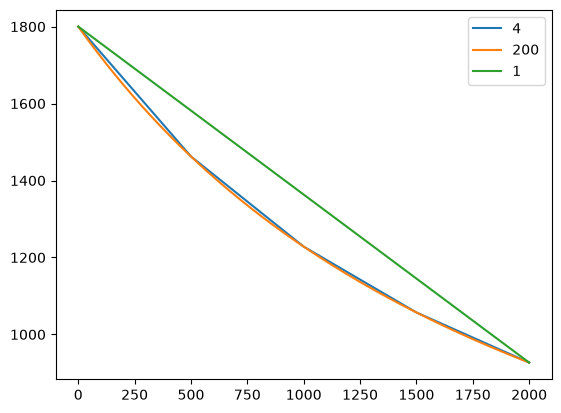

In [9]:
for cl in [cl_1, cl_2, cl_3]:
    L_t = np.array([np.linspace(c.start_length, c.end_length, 2) for c in cl])
    T_s = np.array([c.temp_prof.loc[:, 'surf_temp'] for c in cl])
    T_t = np.array([c.temp_prof.loc[:, 'temp'] for c in cl])
    plt.plot(L_t.flatten(), T_t.flatten(), label=f'{len(cl)}')
plt.legend()
plt.show()